In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import random


In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import v2


In [3]:
def seed_everything(seed=42):
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # set to False for deterministic behavior
    # torch.backends.cudnn.enabled = False # can be set to False if needed
    print(f"Random seed set to {seed}")

# Usage:
seed_everything(0)

Random seed set to 0


In [4]:
# Set the global random seed for reproducibility
np.random.seed(0) 


# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available(): 
    device='cuda:0'
print(device)

cuda:0


# load the train&val sets

In [5]:
filename_train = 'cls_train.pkl'
filename_val = 'cls_val.pkl'

In [6]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [7]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [8]:
train_imgs = []
val_imgs = []

for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    train_imgs += [im.astype(np.float32)]

for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    val_imgs += [im.astype(np.float32)]

# load a pretrained deep neural network and extract deep features

In [9]:
# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available(): 
    device='cuda:0'
print(device)

cuda:0


In [10]:
torch.cuda.device_count()
torch.cuda.empty_cache()


In [11]:
resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = nn.Sequential(*list(resnet18_model.children())[:-1])

In [12]:
print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [17]:
feature_extractor.eval()
feature_extractor.to(device);

In [18]:
trainFea = []
for i in range(len(train_imgs)):
    im = train_imgs[i] / 255.0
    im = data_transform(im)
    fea = feature_extractor(im.to(device).unsqueeze(0)).detach().cpu()
    trainFea += [fea]

In [19]:
valFea = []
for i in range(len(val_imgs)):
    im = val_imgs[i] / 255.0
    im = data_transform(im)
    fea = feature_extractor(im.to(device).unsqueeze(0)).detach().cpu()
    valFea += [fea]

# logistic regression

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
for i in range(len(trainFea)):
    fea = trainFea[i]
    fea = fea.squeeze().detach().cpu().numpy()
    trainFea[i] = fea

for i in range(len(valFea)):
    fea = valFea[i]
    fea = fea.squeeze().detach().cpu().numpy()
    valFea[i] = fea

In [22]:
trainFea = np.asarray(trainFea).squeeze()
valFea = np.asarray(valFea).squeeze()

train_labellist = np.asarray(train_labellist)
val_labellist = np.asarray(val_labellist)

print(trainFea.shape)
print(train_labellist.shape)

print(valFea.shape)
print(val_labellist.shape)

(1275, 512)
(1275,)
(319, 512)
(319,)


In [23]:
clf = LogisticRegression(max_iter=1000).fit(trainFea, train_labellist)

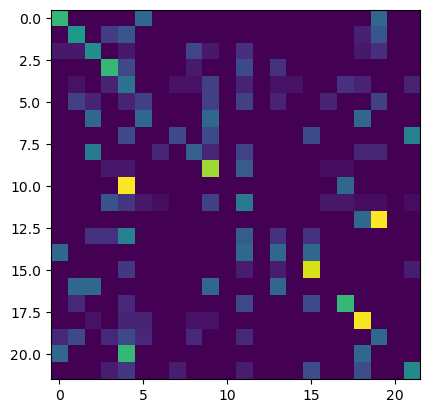

In [24]:
predList = clf.predict(valFea)
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [25]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.282


# one-layer parameters

In [26]:
exp_dir = './exp' # experiment directory, used for reading the init model
prefix = 'vanilla'
postfix = 'v1'
weight_decay = 0.0001

project_name = prefix + '_' + postfix   # we save all the checkpoints in this directory
print(project_name)

save_dir = os.path.join(exp_dir, project_name)

log_filename = os.path.join(save_dir, 'train_%f.log' % weight_decay)
print(save_dir)

if not os.path.exists(save_dir): os.makedirs(save_dir)


vanilla_v1
./exp/vanilla_v1


In [27]:
class ModelArchitecture(nn.Module):
    def __init__(self, num_classes=22, pretrained=False):
        super().__init__()        
        self.cls_head = nn.Linear(512, num_classes)
    def forward(self, x):        
        logits = self.cls_head(x)
        # logits = self.cls_head(self.dropout(feat))
        return logits

In [28]:
myModel = ModelArchitecture(num_classes=numClasses).to(device)
myModel.train()

ModelArchitecture(
  (cls_head): Linear(in_features=512, out_features=22, bias=True)
)

In [29]:
class pollenDataset(Dataset):
    def __init__(self, imgList, labelList):
        self.imgList = imgList
        self.labelList = labelList
        self.current_set_len = len(self.labelList)
    def __len__(self):        
        return self.current_set_len
    
    def __getitem__(self, idx):        
        cur_img = self.imgList[idx]
        cur_label = self.labelList[idx]
        return cur_img, cur_label

In [30]:
trainset = pollenDataset(imgList=trainFea,
                         labelList=train_labellist
                        )

valset = pollenDataset(imgList=valFea,
                       labelList=val_labellist
                      )

In [31]:
len(trainset), trainFea.shape, train_labellist.shape

(1275, (1275, 512), (1275,))

In [32]:
len(valset), valFea.shape, val_labellist.shape

(319, (319, 512), (319,))

In [33]:
batch_size = 32

dataloader_trainset = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
dataloader_valset = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=4)

print(len(dataloader_trainset), len(dataloader_valset))

40 10


In [34]:
i = 0
for sample in dataloader_trainset:
    i+=1
    if i%10==0:
        print(i)
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)

10
20
30
40


In [35]:
cur_Img.shape

torch.Size([27, 512])

In [36]:
output = myModel(cur_Img)

In [37]:
output.shape

torch.Size([27, 22])

In [38]:
epoch_num = 100

optimizer = optim.SGD(myModel.parameters(), lr=0.0005, momentum=0.9, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, epoch_num, eta_min=0)

In [39]:
loss_fn = nn.CrossEntropyLoss()


In [40]:
def append_to_log(log_filename, content_string):
    fn = open(log_filename,'a')
    fn.write('{}\n'.format(content_string))    
    fn.close()


In [41]:
best_epoch_id = -1
best_loss = torch.inf
list_val_loss = np.zeros(epoch_num)
list_train_loss = np.zeros(epoch_num)
bestmodel_filename = os.path.join(save_dir, 'bestmodel_%f.params' % weight_decay)


fn = open(log_filename,'w')
fn.write('{}\n'.format(project_name))
fn.close()

for epoch in range(epoch_num):
    # training
    cur_string = 'epoch %d...' % (epoch)
    print(cur_string)
    append_to_log(log_filename, cur_string)
    
    myModel.train();
    cur_loss = 0
    i=0
    for sample in dataloader_trainset:
        i+=1
        if i%20==0:
            cur_string = '\t%d / %d' %(i, len(dataloader_trainset))
            print(cur_string)
            append_to_log(log_filename, cur_string)

        cur_Img, cur_Label = sample
        cur_Img = cur_Img.to(device)
        cur_Label = cur_Label.type(torch.long).view(-1).to(device)

        
        optimizer.zero_grad()

        
        logits = myModel(cur_Img) 
        loss = loss_fn(logits, cur_Label)
        cur_loss += loss.data
    
        # backward pass
        loss.backward()
        # update weights
        optimizer.step()
        
    scheduler.step()
    cur_loss = cur_loss / len(dataloader_trainset)
    list_train_loss[epoch] = cur_loss
    cur_string = '\ttrain CE: %.4f' % (cur_loss)
    print(cur_string)
    append_to_log(log_filename, cur_string)
    
    # evaluation
    cur_string = '   evaluation...'
    print(cur_string)
    append_to_log(log_filename, cur_string)
    myModel.eval();
    cur_loss = 0
    for sample in dataloader_valset:
        cur_Img, cur_Label = sample
        cur_Img = cur_Img.to(device)
        cur_Label = cur_Label.to(device)
        output = myModel(cur_Img)
        tmp = loss_fn(output, cur_Label)
        cur_loss += tmp.data
    cur_loss = cur_loss/len(dataloader_valset)
    list_val_loss[epoch] = cur_loss
    
    if cur_loss<best_loss:
        best_epoch_id = epoch
        best_loss = cur_loss
        torch.save(myModel.state_dict(), bestmodel_filename)
        
    cur_string = '\tcurrent CE: %.4f, best CE: %.4f at epoch-%d' % (cur_loss, best_loss, best_epoch_id)
    print(cur_string)
    append_to_log(log_filename, cur_string)

epoch 0...
	20 / 40
	40 / 40
	train CE: 2.9049
   evaluation...
	current CE: 2.7792, best CE: 2.7792 at epoch-0
epoch 1...
	20 / 40
	40 / 40
	train CE: 2.7068
   evaluation...
	current CE: 2.6877, best CE: 2.6877 at epoch-1
epoch 2...
	20 / 40
	40 / 40
	train CE: 2.6058
   evaluation...
	current CE: 2.6153, best CE: 2.6153 at epoch-2
epoch 3...
	20 / 40
	40 / 40
	train CE: 2.5225
   evaluation...
	current CE: 2.5545, best CE: 2.5545 at epoch-3
epoch 4...
	20 / 40
	40 / 40
	train CE: 2.4551
   evaluation...
	current CE: 2.4965, best CE: 2.4965 at epoch-4
epoch 5...
	20 / 40
	40 / 40
	train CE: 2.3872
   evaluation...
	current CE: 2.4555, best CE: 2.4555 at epoch-5
epoch 6...
	20 / 40
	40 / 40
	train CE: 2.3324
   evaluation...
	current CE: 2.4123, best CE: 2.4123 at epoch-6
epoch 7...
	20 / 40
	40 / 40
	train CE: 2.2835
   evaluation...
	current CE: 2.3796, best CE: 2.3796 at epoch-7
epoch 8...
	20 / 40
	40 / 40
	train CE: 2.2400
   evaluation...
	current CE: 2.3500, best CE: 2.3500 at 

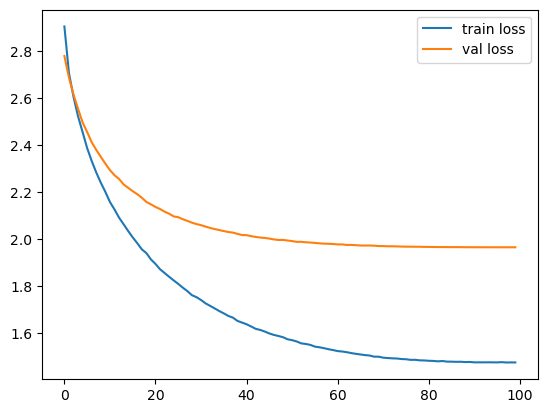

In [42]:
plt.plot(list_train_loss, label='train loss')
plt.plot(list_val_loss, label='val loss')
plt.legend()

# Use the last checkpoint

In [43]:
myModel.eval();
predList = []
for sample in dataloader_valset:
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)
    logits = myModel(cur_Img).detach()
    output = F.softmax(logits, dim=0)
    output = output.cpu().numpy()
    output = np.argmax(output, 1)
    predList = np.concatenate((predList, output))

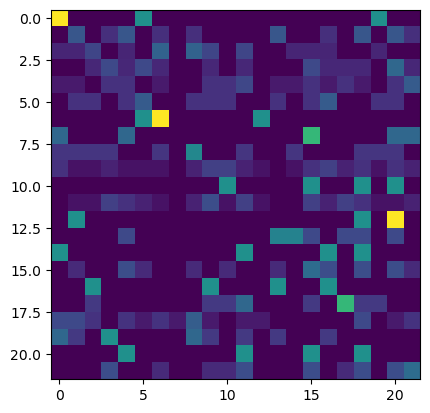

In [44]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [45]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.159


# Use the selected checkpoint 

In [46]:
bestmodel_filename

'./exp/vanilla_v1/bestmodel_0.000100.params'

In [47]:
myModel = ModelArchitecture(num_classes=numClasses).to(device)
myModel.load_state_dict(torch.load(bestmodel_filename))

<All keys matched successfully>

In [48]:
# A = torch.load(bestmodel_filename)

In [49]:
myModel.eval();
predList = []
for sample in dataloader_valset:
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)
    logits = myModel(cur_Img).detach()
    output = F.softmax(logits, dim=0)
    output = output.cpu().numpy()
    output = np.argmax(output, 1)
    predList = np.concatenate((predList, output))

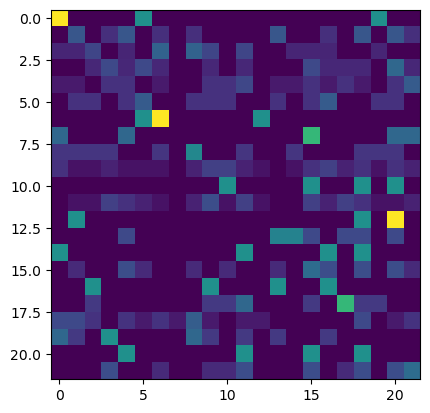

In [50]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [51]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.159
